# Day 1 数据理解：AI4I 2020 工业设备故障数据集

## 项目目标

本项目基于 AI4I 2020 工业数据集，对设备故障影响因素进行分析，并在后续阶段建立基础预测模型，为预测性维护提供参考。

## 本阶段边界

今天只做数据理解：读取数据、认识字段、明确业务问题和后续分析方向。今天不做建模、不调参，也不进入复杂 EDA。

## 需要回答的 5 个业务问题

1. 整体设备故障率是多少？也就是全部记录中，`Machine failure = 1` 的比例有多高？
2. 不同产品类型的故障率是否有差异？例如 `L`、`M`、`H` 三类产品是否有不同的故障风险？
3. 刀具磨损越高，设备发生故障的可能性是否越高？这里重点关注 `Tool wear [min]` 和 `Machine failure` 的关系。
4. 温度、转速、扭矩和故障是否存在明显关系？也就是观察 `Air temperature [K]`、`Process temperature [K]`、`Rotational speed [rpm]`、`Torque [Nm]` 与故障之间的联系。
5. 各类故障原因的分布如何？例如 `TWF`、`HDF`、`PWF`、`OSF`、`RNF` 哪一种更常见？

## 1. 读取数据

下面先用最基础的 pandas 代码读取 CSV 文件。请注意：这里假设 notebook 是从项目根目录运行的，所以数据路径写成 `data/raw/ai4i2020.csv`。

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

## 2. 代码逐段解释

### `import pandas as pd`

这行代码的作用是导入 pandas 工具包，并把它简写成 `pd`。pandas 是 Python 里最常用的数据表处理工具，可以把 CSV 文件读成类似 Excel 表格的数据结构。

在这个项目里，AI4I 2020 数据集是一个 CSV 表格。我们用 pandas 来读取、查看和分析这张表。

你需要重点理解：这一步只是准备工具，还没有真正读取数据。

### `df = pd.read_csv("data/raw/ai4i2020.csv")`

这行代码会从 `data/raw/ai4i2020.csv` 读取原始数据，并保存到变量 `df` 中。

`df` 是 DataFrame 的常见缩写。你可以把它理解成 Python 里的“数据表”。每一行代表一条设备运行记录，每一列代表一个字段，例如温度、转速、扭矩、刀具磨损、是否故障等。

执行后重点观察：如果没有报错，说明文件路径正确，CSV 成功读进来了。如果报错 `FileNotFoundError`，通常说明当前 notebook 的运行目录不在项目根目录，或者路径写错了。

### `df.head()`

这行代码会显示数据表的前 5 行。

它的作用类似于先“扫一眼表格长什么样”。在这个项目里，你应该重点看：有哪些列、每列大概是什么格式、`Machine failure` 是否是 0/1、`TWF/HDF/PWF/OSF/RNF` 是否也是 0/1。

执行后重点观察：

- `UDI` 看起来像记录编号。
- `Product ID` 是产品编号。
- `Type` 是产品类型，通常有 `L`、`M`、`H`。
- 温度、转速、扭矩、刀具磨损是设备运行状态。
- `Machine failure` 是总故障标记。
- `TWF/HDF/PWF/OSF/RNF` 是不同故障原因的标记。

### `df.shape`

这行代码会返回数据表的形状，格式是 `(行数, 列数)`。

在这个项目里，它可以帮助你回答：“这个数据集有多少条记录？有多少个字段？”

执行后重点观察：行数代表样本数量，列数代表字段数量。AI4I 2020 数据集通常是 10000 行、14 列。

### `df.columns`

这行代码会显示所有列名。

在这个项目里，它的作用是帮你确认字段是否完整，以及字段名有没有空格、单位或特殊符号。例如 `Air temperature [K]` 里面带有单位 `[K]`，表示开尔文温度；`Tool wear [min]` 里面带有单位 `[min]`，表示分钟。

执行后重点观察：后续写代码时，列名必须和这里显示的完全一致，包括大小写、空格和中括号。

### `df.info()`

这行代码会显示数据表的整体信息，包括每列的非空数量和数据类型。

在这个项目里，它可以帮助你快速判断：有没有缺失值、哪些列是数字、哪些列是文本。

执行后重点观察：

- 每列的 `Non-Null Count` 是否等于总行数。如果相等，说明这一列没有缺失值。
- `Type` 和 `Product ID` 通常是文本类型。
- 温度、转速、扭矩、刀具磨损、故障标记通常是数值类型。
- `Machine failure` 是今天最重要的目标字段。

## 3. 字段说明表

| 字段名 | 中文含义 | 你理解的业务意义 | 类型 |
|---|---|---|---|
| `UDI` | 唯一记录编号 | 每一条设备运行记录的编号，主要用于区分样本，不直接代表设备状态好坏。 | 编号字段，整数 |
| `Product ID` | 产品编号 | 某个产品或工件的唯一标识，可以帮助追踪具体产品，但通常不直接作为判断故障规律的核心特征。 | 类别/文本字段 |
| `Type` | 产品类型 | 产品质量或类型等级，常见为 `L`、`M`、`H`。不同类型产品可能使用场景、负载或加工要求不同，因此故障率可能不同。 | 类别字段 |
| `Air temperature [K]` | 空气温度，单位 K | 设备周围环境温度。环境温度过高可能影响散热，从而增加设备异常风险。 | 数值字段，连续变量 |
| `Process temperature [K]` | 工艺温度，单位 K | 设备加工过程中的温度。它更接近设备实际运行状态，过高或异常变化可能和热相关故障有关。 | 数值字段，连续变量 |
| `Rotational speed [rpm]` | 转速，单位 rpm | 设备旋转部件每分钟转动次数。转速过高或过低都可能影响加工稳定性，也可能和功率、扭矩共同反映负载状态。 | 数值字段，连续变量 |
| `Torque [Nm]` | 扭矩，单位 Nm | 设备旋转时承受的力矩。扭矩可以理解成设备“用力程度”，扭矩过高可能说明负载较大，可能增加故障风险。 | 数值字段，连续变量 |
| `Tool wear [min]` | 刀具磨损时间，单位分钟 | 刀具已经使用或磨损的时间。磨损越久，刀具状态可能越差，发生刀具磨损故障或加工异常的风险可能越高。 | 数值字段，连续变量 |
| `Machine failure` | 是否发生设备故障 | 总故障标记。`1` 表示这条记录发生了设备故障，`0` 表示没有故障。它是后续预测性维护建模最核心的目标字段。 | 目标字段，二分类 0/1 |
| `TWF` | 刀具磨损故障 | Tool Wear Failure。表示是否因为刀具磨损导致故障。它是具体故障原因之一，不是总故障率本身。 | 故障原因标记，0/1 |
| `HDF` | 散热故障 | Heat Dissipation Failure。表示是否因为散热或热量无法有效释放导致故障，通常和温度状态有关。 | 故障原因标记，0/1 |
| `PWF` | 功率故障 | Power Failure。表示是否因为功率状态异常导致故障，可能和转速、扭矩共同反映的设备功率负载有关。 | 故障原因标记，0/1 |
| `OSF` | 过载故障 | Overstrain Failure。表示是否因为设备承受过大应力或过载导致故障，可能和扭矩、刀具磨损、产品类型有关。 | 故障原因标记，0/1 |
| `RNF` | 随机故障 | Random Failure。表示随机性故障，可能不容易由当前这些传感器字段解释。分析时要注意它可能没有明显规律。 | 故障原因标记，0/1 |

## 4. 容易混淆的字段提醒

- `Machine failure` 是总目标字段，表示是否发生故障；`TWF/HDF/PWF/OSF/RNF` 是具体故障类型或原因标记。
- `Air temperature [K]` 是环境空气温度，`Process temperature [K]` 是加工过程温度，两者不是同一个概念。
- `Rotational speed [rpm]` 是转速，`Torque [Nm]` 是扭矩。简单理解：转速看“转得多快”，扭矩看“用力多大”。
- `Product ID` 是产品编号，`Type` 是产品类型。编号通常更像身份标签，类型更适合用来比较不同类别的故障差异。
- 温度单位是 K，不是摄氏度。初学阶段不用急着换算，但要知道它不是日常说的摄氏温度。

## 5. 今天学完后应该能掌握的知识点

1. 知道如何用 `pd.read_csv()` 把 CSV 文件读成 DataFrame。
2. 知道 `df.head()` 用来快速查看前几行数据。
3. 知道 `df.shape` 用来查看数据规模，也就是行数和列数。
4. 知道 `df.columns` 用来查看所有字段名，后续写代码必须严格匹配字段名。
5. 知道 `df.info()` 用来查看字段类型和缺失情况。
6. 能区分目标字段、普通特征字段、故障原因字段。
7. 能用业务语言解释这个数据集为什么和预测性维护有关。

## 6. Day 1 自检标准

完成今天内容后，你应该可以不看网页，自己说清楚下面几件事：

1. 这个数据集是干什么的：它记录了工业设备在不同运行状态下是否发生故障，用来分析设备故障影响因素，并为后续预测性维护建模做准备。
2. 目标字段是哪一列：`Machine failure`，其中 `1` 表示发生故障，`0` 表示没有故障。
3. 主要特征有哪些：产品类型 `Type`，空气温度、工艺温度、转速、扭矩、刀具磨损，以及具体故障原因标记 `TWF/HDF/PWF/OSF/RNF`。
4. 后面准备分析什么：整体故障率、不同产品类型的故障率差异、刀具磨损和故障的关系、温度/转速/扭矩和故障的关系、不同故障类型的分布。
5. 今天不需要做什么：不建模、不调参、不追求复杂图表，先把字段和业务问题理解清楚。

## 7. 数据质量检查

Day 1 已经完成数据读取和字段理解；Day 2 的目标是判断这份数据是否足够完整、稳定，是否适合进入后续探索性分析。

本节重点检查缺失值、重复值、数值字段范围、总故障标签分布、产品类型分布和各故障类型分布。这里不做建模、不调参，也不急着画复杂图表。

### 7.1 缺失值检查

工业设备数据中的缺失值可能来自传感器采集失败、系统写入异常或数据同步问题。这里重点确认关键字段是否完整，尤其是传感器字段和目标字段 `Machine failure`。

In [7]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

**关注点：**如果关键传感器字段或目标字段存在缺失，会影响故障率判断和后续建模。当前数据检查结果显示各字段缺失值为 0，说明这份数据在完整性上比较理想，暂时不需要做缺失值填补。

### 7.2 重复值检查

重复记录会让某些运行状态被重复计入，可能影响故障率、类别分布和后续模型学习。

In [8]:
df.duplicated().sum()

np.int64(0)

**关注点：**当前完全重复行数量为 0，说明当前故障率和分布统计没有被重复记录放大，暂时不需要做去重处理。

### 7.3 数值字段描述统计

描述统计用于初步判断数值字段范围是否合理。这里重点看温度、转速、扭矩和刀具磨损是否出现明显不合理的极端值。

In [9]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


**关注点：**重点看 `min`、`max`、`mean`、`25%`、`50%`、`75%`。在设备故障场景中，极端温度、极端转速、极端扭矩、过高刀具磨损都可能是后续异常值检查和故障关系分析的入口。当前统计范围初步合理，但是否存在异常分布，还需要后续结合箱线图、直方图和分组对比进一步判断。

### 7.4 总故障标签分布

检查目标字段 `Machine failure` 的分布，判断故障事件是否属于低频事件。

In [10]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [11]:
df["Machine failure"].value_counts(normalize=True)

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

**关注点：**当前总故障样本为 339 条，非故障样本为 9661 条，故障率约为 3.39%。这说明设备故障是低频事件。后续建模时不能只看准确率，否则模型可能倾向于把大多数样本都判断为“无故障”。

### 7.5 类别字段 `Type` 分布

检查不同产品类型的样本数量，判断后续分组比较时是否需要注意样本量差异。

In [12]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

**关注点：**当前 `Type` 分布为 `L=6000`、`M=2997`、`H=1003`。产品类型本身不均衡，后续比较不同类型故障风险时，不能只看故障数量，还要看每个类型内部的故障率。

### 7.6 各故障类型字段分布

检查 `TWF`、`HDF`、`PWF`、`OSF`、`RNF` 五类故障标记的分布。

In [13]:
failure_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]

for col in failure_cols:
    print(col)
    print(df[col].value_counts())
    print("-" * 30)

TWF
TWF
0    9954
1      46
Name: count, dtype: int64
------------------------------
HDF
HDF
0    9885
1     115
Name: count, dtype: int64
------------------------------
PWF
PWF
0    9905
1      95
Name: count, dtype: int64
------------------------------
OSF
OSF
0    9902
1      98
Name: count, dtype: int64
------------------------------
RNF
RNF
0    9981
1      19
Name: count, dtype: int64
------------------------------


**关注点：**五类故障原因都是稀疏事件，计数分别为 `TWF=46`、`HDF=115`、`PWF=95`、`OSF=98`、`RNF=19`。解释具体故障类型时要避免过度下结论，因为少数类样本很少，比例容易受少量记录影响。

### 7.7 补充：故障标签一致性检查

这一步不是复杂 EDA，而是一个轻量的数据质量核对：检查总故障标记和五类故障原因标记之间是否完全一致。

In [14]:
failure_type_count = df[failure_cols].sum(axis=1)

label_consistency = {
    "有至少一种故障类型的记录数": (failure_type_count > 0).sum(),
    "有多个故障类型的记录数": (failure_type_count > 1).sum(),
    "Machine failure=1 但无具体故障类型的记录数": ((df["Machine failure"] == 1) & (failure_type_count == 0)).sum(),
    "Machine failure=0 但有具体故障类型的记录数": ((df["Machine failure"] == 0) & (failure_type_count > 0)).sum(),
}

label_consistency

{'有至少一种故障类型的记录数': np.int64(348),
 '有多个故障类型的记录数': np.int64(24),
 'Machine failure=1 但无具体故障类型的记录数': np.int64(9),
 'Machine failure=0 但有具体故障类型的记录数': np.int64(18)}

**关注点：**当前五类故障原因标记并不是和 `Machine failure` 完全一一对应：存在少量 `Machine failure=1` 但没有具体故障类型的记录，也存在少量 `Machine failure=0` 但有具体故障类型的记录。后续正式分析时，需要明确主分析目标是预测总故障，还是解释具体故障类型。

## 8. 数据质量判断结论

从 Day 2 的基础检查结果看，数据整体结构较完整：共有 10000 条记录、14 个字段，各字段缺失值为 0，完全重复行数量为 0。因此，从数据完整性和记录唯一性角度看，这份数据适合进入后续探索性分析。

需要重点注意的是，目标字段 `Machine failure` 存在明显类别不平衡：非故障样本 9661 条，故障样本 339 条，故障率约为 3.39%。这符合工业设备故障的低频特征，但也意味着后续分析和建模阶段不能只依赖准确率，需要关注故障样本的识别能力。

类别字段 `Type` 的样本分布也不均衡，其中 `L` 类型样本最多，`H` 类型样本最少。后续比较不同产品类型的故障风险时，应优先比较各类型内部故障率，而不是直接比较故障数量。

五类故障原因字段 `TWF/HDF/PWF/OSF/RNF` 都属于稀疏事件，其中 `RNF` 样本尤其少。解释具体故障类型时，应避免基于很少的样本做过强结论。当前数值字段范围初步合理，但仍需在后续 EDA 中结合图表进一步检查异常值、偏态分布和不同故障状态下的差异。

此外，总故障标记和具体故障类型标记之间存在少量不完全一致的记录。后续需要明确：主线任务以 `Machine failure` 作为总故障目标，故障类型字段更多用于解释故障构成和辅助分析。

## 9. 预测性维护视角解释

在真实工业场景中，故障通常是低频但高价值事件。大多数时间设备是正常运行的，但一旦发生故障，可能带来停机、维修成本、产能损失或质量风险。因此，3.39% 的总故障率并不代表故障“不重要”，反而说明后续分析要特别重视少数故障样本。

缺失值和重复值检查是为了确认数据是否可信。没有缺失值说明这份数据在采集完整性上较好；没有重复值说明当前故障率和分布统计没有被重复记录放大。类别分布和故障类型分布则帮助我们理解样本结构：产品类型不均衡会影响分组比较，故障类型稀疏会影响原因解释的稳定性。

Day 2 完成后，最合理的下一步是进入基础 EDA：先做单变量分析和目标字段分布分析，再做产品类型、刀具磨损、温度、转速、扭矩与故障之间的双变量关系分析。等这些规律看清楚后，再进入异常值处理、特征工程和建模。

## 10. Day 3 第一轮 EDA 图表分析

Day 1 和 Day 2 已经完成字段理解与基础数据质量检查。Day 3 开始进入第一轮 EDA，重点从图表和分组统计中观察业务现象。

本轮 EDA 仍以总故障标签 `Machine failure` 为主线。原因是 Day 2 已经发现：总故障率只有约 3.39%，具体故障类型字段 `TWF/HDF/PWF/OSF/RNF` 都比较稀疏，并且与总故障标签存在少量不完全一致记录。因此今天先不深入拆分具体故障原因，而是先观察哪些产品类型和运行状态与总故障更相关。

本节只做第一轮探索，不进入建模、不调参、不做复杂特征工程。图表结论主要用于形成后续分析假设，不能直接解释为因果关系。

### 10.1 图表环境设置

下面统一设置绘图参数，让后续图表风格保持一致。这里使用 `matplotlib` 和 pandas 自带绘图，保持简单、稳定、可复现。

In [15]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 11

### 10.2 故障标签分布：确认类别不平衡

Day 2 已经知道总故障率约为 3.39%。这里用柱状图把故障/非故障样本数量画出来，直观看类别不平衡程度。

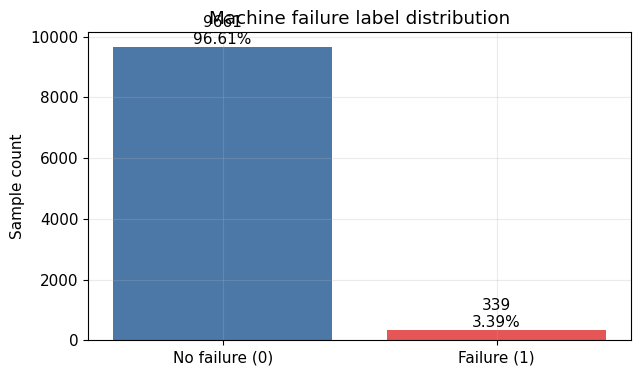

In [16]:
target_counts = df["Machine failure"].value_counts().sort_index()
target_rates = df["Machine failure"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["No failure (0)", "Failure (1)"], target_counts.values, color=["#4C78A8", "#E45756"])

for bar, count, rate in zip(bars, target_counts.values, target_rates.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}\n{rate:.2%}",
        ha="center",
        va="bottom"
    )

ax.set_title("Machine failure label distribution")
ax.set_ylabel("Sample count")
plt.show()

**图后解读：**非故障样本远多于故障样本，故障样本只占约 3.39%。这符合工业设备故障低频发生的特点，但也意味着后续无论做 EDA 还是建模，都要特别关注少数故障样本。图上如果只看柱子高度，故障组很容易被“压扁”，所以后续更适合结合故障率、箱线图和分组统计一起看。

### 10.3 产品类型分布：观察样本结构

先看 `Type` 的样本量分布。这个图不是直接回答故障风险，而是告诉我们：后续做产品类型对比时，每个类型的样本基数是否一致。

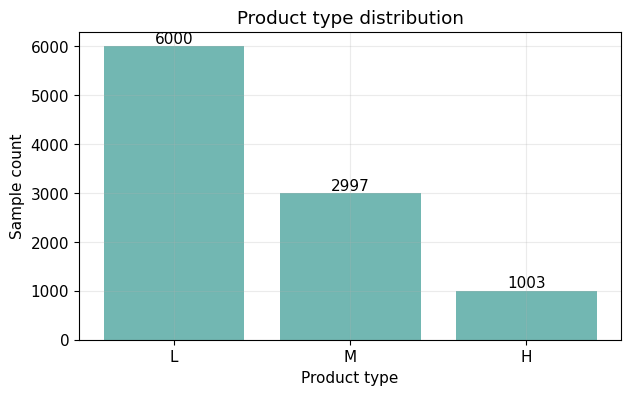

In [17]:
type_order = ["L", "M", "H"]
type_counts = df["Type"].value_counts().reindex(type_order)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(type_counts.index, type_counts.values, color="#72B7B2")

for bar, count in zip(bars, type_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{count}", ha="center", va="bottom")

ax.set_title("Product type distribution")
ax.set_xlabel("Product type")
ax.set_ylabel("Sample count")
plt.show()

**图后解读：**`L` 类型样本最多，`M` 次之，`H` 最少。由于产品类型样本量不均衡，后面不能直接比较“故障数量”，否则样本多的类型天然更容易出现更多故障。更合理的比较方式是看各类型内部故障率。

### 10.4 不同产品类型故障率：比较内部风险

这是制造业分析中很典型的问题：不同产品类型的故障风险是否不同。这里用每个类型内部的故障率来比较，而不是只比较故障数量。

In [18]:
type_fail = df.groupby("Type")["Machine failure"].agg(["count", "sum", "mean"])
type_fail.columns = ["total_cnt", "fail_cnt", "fail_rate"]
type_fail = type_fail.loc[type_order]

type_fail

,total_cnt,fail_cnt,fail_rate
Type,,,
L,6000,235,0.039167
M,2997,83,0.027694
H,1003,21,0.020937


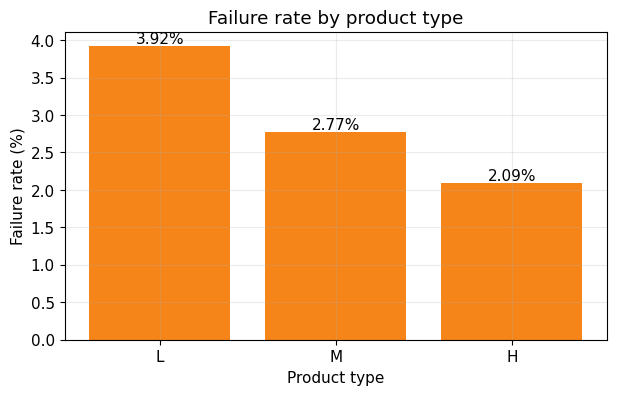

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
fail_rate_pct = type_fail["fail_rate"] * 100
bars = ax.bar(fail_rate_pct.index, fail_rate_pct.values, color="#F58518")

for bar, rate in zip(bars, fail_rate_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{rate:.2f}%", ha="center", va="bottom")

ax.set_title("Failure rate by product type")
ax.set_xlabel("Product type")
ax.set_ylabel("Failure rate (%)")
plt.show()

**图后解读：**从当前数据看，`L` 类型故障率约为 3.92%，`M` 类型约为 2.77%，`H` 类型约为 2.09%。这说明不同产品类型之间可能存在故障风险差异。不过这里仍然只能说“存在相关迹象”，不能直接说产品类型导致故障；后续还需要结合扭矩、转速、刀具磨损等运行状态一起分析。

### 10.5 刀具磨损与故障关系

刀具磨损是预测性维护中很有业务意义的变量。如果故障组的刀具磨损明显更高，说明它可能是一个重要预警信号。这里先用箱线图比较故障组和非故障组的磨损分布，再用分箱统计观察磨损区间内的故障率。

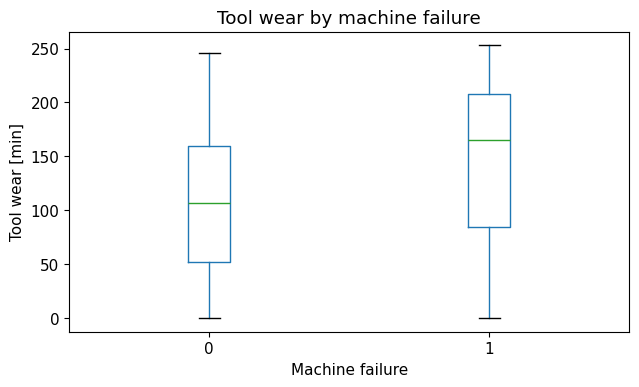

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(column="Tool wear [min]", by="Machine failure", ax=ax, grid=False)

ax.set_title("Tool wear by machine failure")
ax.set_xlabel("Machine failure")
ax.set_ylabel("Tool wear [min]")
plt.suptitle("")
plt.show()

In [21]:
df["wear_group"] = pd.cut(
    df["Tool wear [min]"],
    bins=[0, 50, 100, 150, 200, 300],
    include_lowest=True
)

wear_fail = df.groupby("wear_group", observed=False)["Machine failure"].agg(["count", "sum", "mean"])
wear_fail.columns = ["total_cnt", "fail_cnt", "fail_rate"]

wear_fail

,total_cnt,fail_cnt,fail_rate
wear_group,,,
"(-0.001, 50.0]",2396,52,0.021703
"(50.0, 100.0]",2271,53,0.023338
"(100.0, 150.0]",2295,50,0.021786
"(150.0, 200.0]",2276,66,0.028998
"(200.0, 300.0]",762,118,0.154856


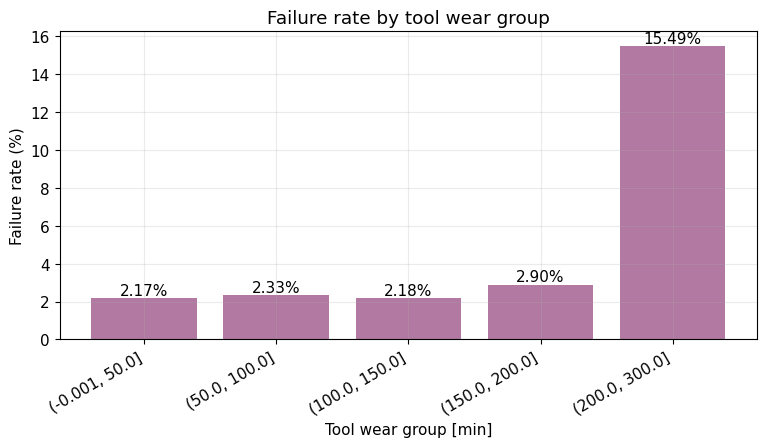

In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
wear_rate_pct = wear_fail["fail_rate"] * 100
bars = ax.bar(wear_rate_pct.index.astype(str), wear_rate_pct.values, color="#B279A2")

for bar, rate in zip(bars, wear_rate_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{rate:.2f}%", ha="center", va="bottom")

ax.set_title("Failure rate by tool wear group")
ax.set_xlabel("Tool wear group [min]")
ax.set_ylabel("Failure rate (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

**图后解读：**故障组的刀具磨损整体更高，分箱结果也显示 `Tool wear [min]` 超过 200 分钟后，故障率明显上升到约 15.49%。这在预测性维护里很有价值：刀具磨损可能不是唯一原因，但它可以作为维护预警的重要信号。需要注意的是，分箱边界是人为设置的，且高磨损区间样本量较少，后续应结合更多图表和模型验证这个规律是否稳定。

### 10.6 关键数值变量与故障关系

下面比较故障组和非故障组在温度、转速、扭矩、刀具磨损上的差异。重点关注故障组是否出现系统性偏移：例如温度更高、转速更低、扭矩更高、刀具磨损更严重。

In [23]:
numeric_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

failure_mean_compare = df.groupby("Machine failure")[numeric_cols].mean()
failure_mean_compare

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


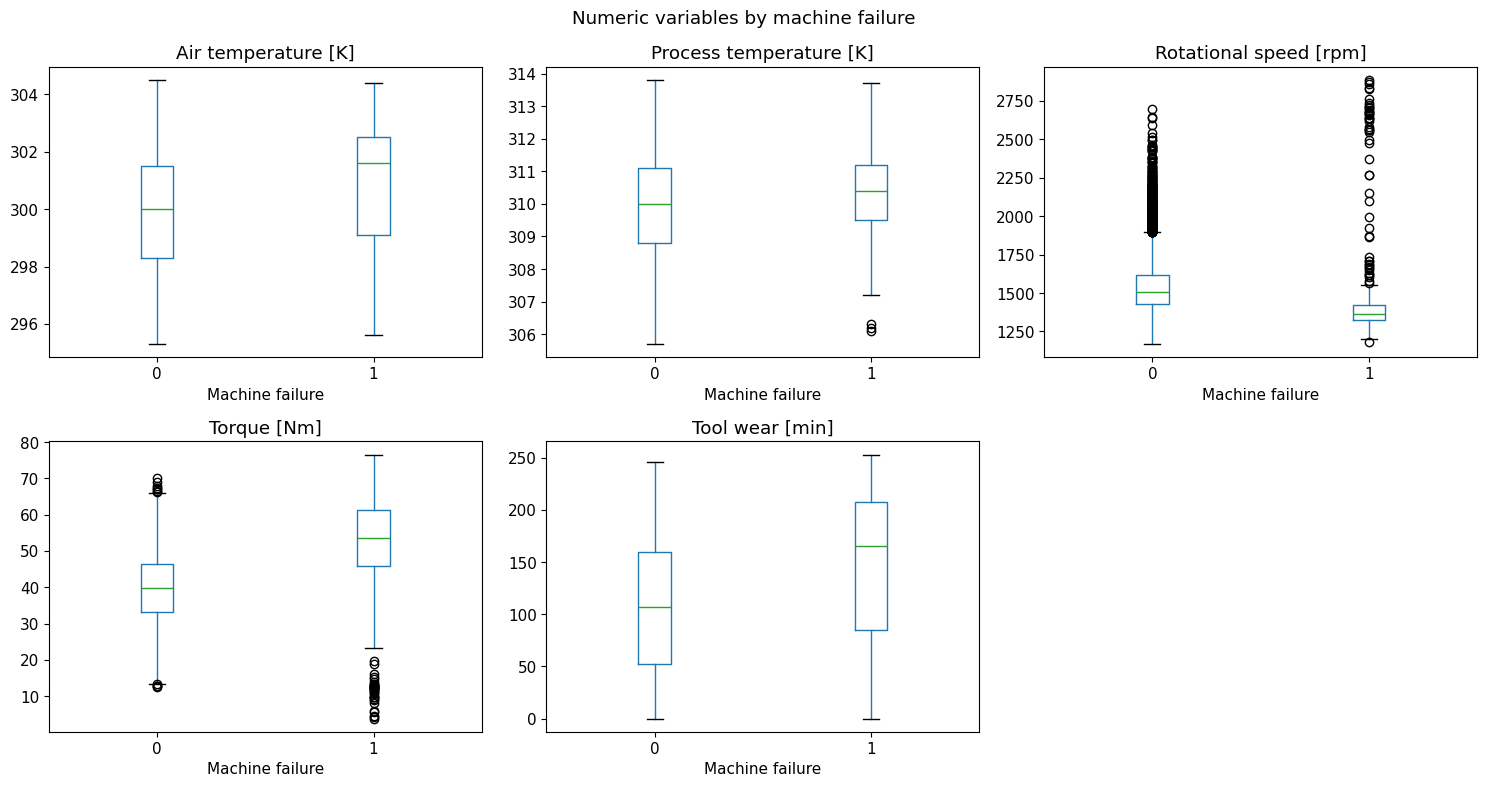

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    df.boxplot(column=col, by="Machine failure", ax=ax, grid=False)
    ax.set_title(col)
    ax.set_xlabel("Machine failure")

axes[-1].axis("off")
plt.suptitle("Numeric variables by machine failure")
plt.tight_layout()
plt.show()

**图后解读：**从均值和箱线图看，故障组相比非故障组呈现出几个明显方向：空气温度略高，工艺温度略高，转速更低，扭矩更高，刀具磨损更高。其中扭矩、转速、刀具磨损的差异更值得关注。业务上可以理解为：设备在高负载或异常负载状态下，可能表现为更高扭矩、更低转速，同时刀具磨损累积更严重。不过这些仍然是相关性迹象，不能直接等同于因果结论。

## 11. Day 3 第一轮 EDA 结论

第一轮 EDA 的核心目标是从图表中形成后续分析假设。结合 Day 2 的数据质量检查结果，本轮分析可以得到以下阶段性结论：

1. `Machine failure` 是明显不平衡标签，故障样本只占约 3.39%。后续分析和建模必须关注少数故障样本，不能只看总体准确率或总体样本数量。
2. `Type` 的样本量不均衡，`L` 类型样本最多。比较产品类型风险时，故障率比故障数量更有意义。当前 `L` 类型故障率相对更高，值得后续进一步拆解。
3. 刀具磨损与故障存在较明显相关迹象，尤其当磨损超过 200 分钟后，故障率明显升高。这可能是预测性维护中重要的预警变量。
4. 故障组在扭矩、转速、刀具磨损上与非故障组存在明显差异：故障组平均扭矩更高、平均转速更低、平均刀具磨损更高。这些变量后续应作为重点分析对象。
5. 温度变量在故障组也有一定偏移，但差异相对没有扭矩、转速、刀具磨损那么直观。后续可以结合散热故障 `HDF` 或更细分的图表继续观察。

需要注意的是，今天的图表只能说明变量和故障之间存在相关迹象，不能直接证明因果关系。下一步应继续做更系统的双变量分析、异常值检查和相关性分析，再决定哪些变量进入后续特征工程和建模。